Árbol de decisión sin poda:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


Árbol podado (max_depth=3, min_samples_split=5):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



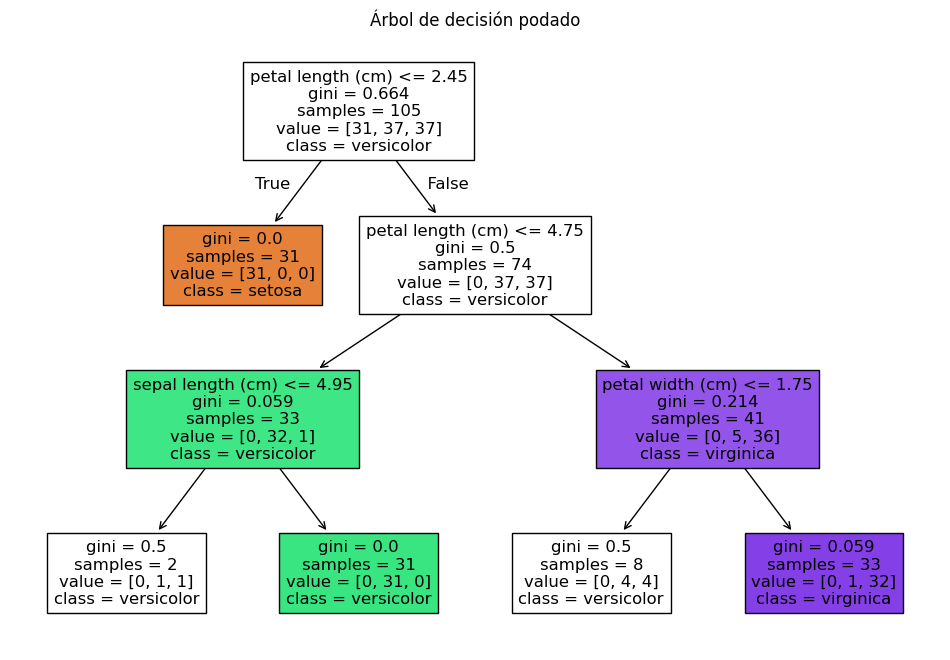

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Cargar el dataset Iris
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# Dividir el dataset en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Árbol sin poda (profundidad máxima por defecto = hasta que todas las hojas sean puras)
modelo_tree = DecisionTreeClassifier(random_state=42)
modelo_tree.fit(X_train, y_train)
y_pred_tree = modelo_tree.predict(X_test)

print("Árbol de decisión sin poda:")
print(classification_report(y_test, y_pred_tree, target_names=target_names))

# Cambio para aplicación: limitar la profundidad y el mínimo de muestras por hoja para evitar overfitting
modelo_podado = DecisionTreeClassifier(max_depth=3, min_samples_split=5, min_samples_leaf=2, random_state=42)
modelo_podado.fit(X_train, y_train)
y_pred_podado = modelo_podado.predict(X_test)

print("\nÁrbol podado (max_depth=3, min_samples_split=5):")
print(classification_report(y_test, y_pred_podado, target_names=target_names))

# Visualización del árbol (opcional)
plt.figure(figsize=(12,8))
tree.plot_tree(modelo_podado, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.title("Árbol de decisión podado")
plt.show()